## Machine Learning : Theory and Applications (2025/26)
Simona Cocco & Vito Dichio

# Tutorial 1 (SOLUTION)

**Topic:** Poisson processes, Bayesian inference, and spike trains  

**Goals:**  
1) simulate Poisson spike trains;  
2) compute the posterior for rate under a simple prior;  
3) compare model vs data.

**Bibliography:**
From Statistical Physics to Data-Driven Modelling: with Applications to Quantitative Biology (1st Edition), by Simona Cocco, Rémi Monasson, Francesco Zamponi -- 2022

### Setup

In [5]:
# Import the necessary packages
import matplotlib.pyplot as plt
import numpy as np 

# Set a seed for reproducibility
SEED = 11092025
rng = np.random.default_rng(SEED)

## Part A — Simulated data
In a homogeneous Poisson process with rate $\theta$ (spikes/s), the spike count in a window of length $T$ is
$$
\Pr[X=k] = \frac{(\theta T)^k e^{-\theta T}}{k!}, \quad k=0,1,2,\dots
$$

**Question A1:** Simulate a Poisson process with rate $\theta=0.5$, and different observation times $T=10, 100, 1000$. Plot the spike times for each $T$.

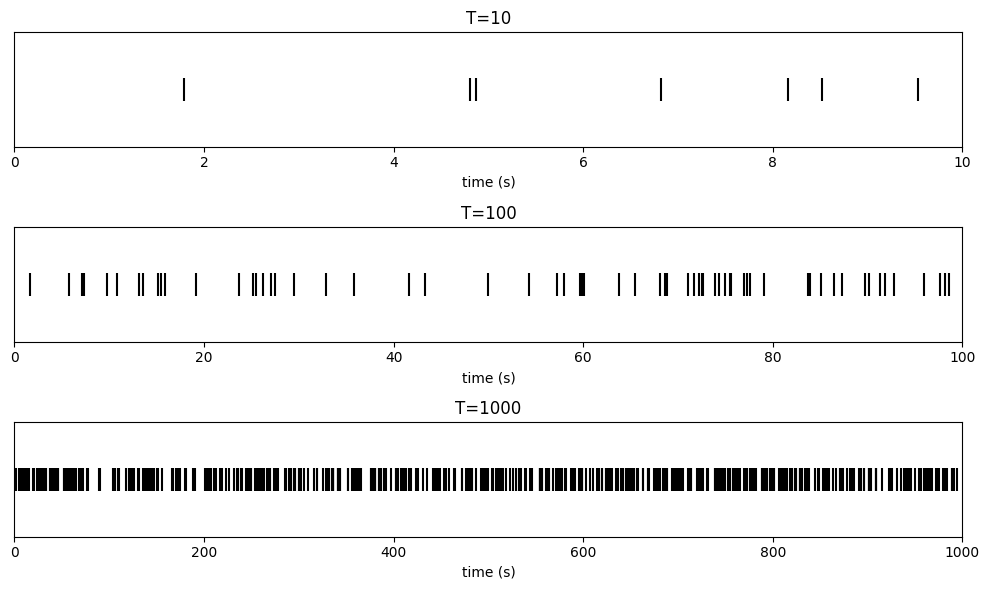

In [6]:
def simulate_poisson(rate, T, rng):
    """Simulate spike times for a Poisson process with given rate and duration T."""
    
    # Step 1: sample the number of spikes
    # Counts in [0,T] follow Poisson(rate * T)
    y = rng.poisson(rate * T)
    
    # Step 2: sample spike times uniformly in [0,T]
    # Given y spikes, their times are i.i.d. uniform
    spike_times = rng.uniform(0, T, size=y)
    
    # Step 3: sort spike times so they appear in chronological order
    return np.sort(spike_times)


def plot_raster(spikes, T, title=None):
    plt.vlines(spikes, -0.2, 0.2, color='black')
    plt.xlim(0, T)
    plt.ylim(-1, 1)
    plt.xlabel("time (s)")
    if title:
        plt.title(title)

# Question 1
rate = 0.5
Ts = [10, 100, 1000]
samples = [simulate_poisson(rate, T, rng) for T in Ts]

# Create a new figure with specified size
plt.figure(figsize=(10, 6))
# Loop over each observation window T and its corresponding spike times
for i, (T, spikes) in enumerate(zip(Ts, samples), 1):
    # Create a subplot for each T (stacked vertically)
    plt.subplot(len(Ts), 1, i)
    # Plot the spike raster for the current T
    plot_raster(spikes, T, title=f"T={T}")
    # Remove y-axis ticks and labels for clarity
    plt.tick_params(left=False, labelleft=False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()



**Question A2.** From the observed counts (not spike times), compute the posterior distribution of the rate parameter $\theta$.  
Assume a uniform prior on $\theta>0$.

## Derivation of the posterior distribution

We observe a **homogeneous Poisson process** with constant rate $\theta$ (spikes/s) over duration $T$.  Our "data" is the spike count $y$ in $[0,T]$.

#### Setup
Let's calculate the posterior distribution of the rate parameter $\theta$ given observed spike counts by applying Bayes' theorem.
$$
P(\theta \mid y) = \frac{P(y \mid \theta) P(\theta)}{P(y)}.
$$

#### Likelihood (Poisson)
Let $Y$ be the spike count in $[0,T]$. By definition of a Poisson process,

$$
P(Y=y \mid \theta) = \frac{(\theta T)^y e^{-\theta T}}{y!}, \qquad y=0,1,2,\dots
$$

#### Prior
Before looking at the data, every positive rate $\theta$ is equally likely. We use the (improper) uniform prior on the nonnegative reals: $P(\theta)\propto 1$ for $\theta \ge 0$.  

#### Propobability of the evidence
The evidence $P(y)$ is a normalizing constant ensuring the posterior integrates to 1.

$$
P(y) = \int_0^\infty P(y|\theta)P(\theta)\mathrm{d}\theta = \int_0^\infty \frac{(\theta T)^y e^{-\theta T}}{y!} \mathrm{d}\theta = \frac{1}{T} \frac{1}{y!} \int_0^\infty x^y e^{-x} \mathrm{d}x = \frac{1}{T} \frac{\Gamma(y+1)}{y!}  = \frac{1}{T},
$$
where the [Gamma function](https://en.wikipedia.org/wiki/Gamma_function) was used:
$$
\Gamma(x) \equiv \int_0^\infty t^{x-1}\exp(-t) \mathrm dt
$$
and the fact that $\Gamma(n+1) = n!$ for $n \in \mathbb{N}$.

#### Posterior
Putting it all together, the posterior reads:

$$
P(\theta \mid y) = \frac{T^{y+1}}{\Gamma(y+1)} \, \theta^{y} e^{-T\theta}, \quad \theta \ge 0.
$$

-----

**Comments**
1. This was a highly uncommon case, since the probability of the evidence $P(y)$ could be computed analytically. In general, this integral is often intractable.
2. The posterior is in fact a [**Gamma distribution**](https://en.wikipedia.org/wiki/Gamma_distribution), with probability density $$ f(x; \alpha, \beta) = \frac{\beta^\alpha}{\Gamma(\alpha)}\, x^{\alpha-1} e^{-\beta x}, \quad x \ge 0, $$where $\alpha$ is the **shape** parameter and $\beta$ the **rate** (inverse of the scale).
   In our case, the posterior has  $\alpha = y+1,\ \ \beta = T.$ This is available in the scipy library as ['scipy.stats.gamma'](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gamma.html) .

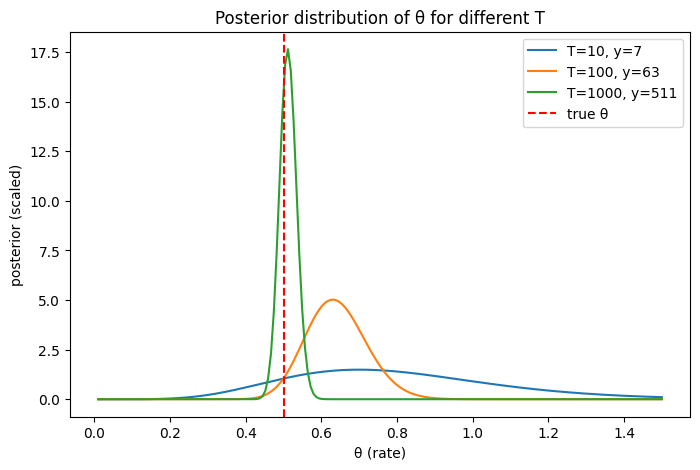

In [7]:
# --- Numerical approach ---
# We compute the exact posterior, and plot it for different T.

from scipy.special import loggamma

def log_likelihood(theta, y, T):
    """Log-likelihood of observing y spikes in [0,T] for rate θ."""
    # Using log form is numerically stable:
    # - avoids overflow in (θT)^y and factorial(y)
    # - avoids underflow in exp(-θT)
    # - loggamma(y+1) safely computes log(y!) for large y
    return y * np.log(theta * T) - (theta * T) - loggamma(y + 1)


def posterior(theta, y, T):
    """Posterior distribution for rate theta with uniform prior."""
    return T*np.exp(log_likelihood(theta, y, T))

# Alternatively
def posterior_scipy(theta, y, T):
    """Posterior distribution using scipy's gamma pdf."""
    from scipy.stats import gamma
    alpha = y + 1    # shape
    beta = T         # rate
    scale = 1 / beta # scipy expects scale = 1/rate
    return gamma.pdf(theta, a=alpha, scale=scale)

#------------------------------------------------#

# Example: posterior for the simulations in Question 1

# Create a grid of theta values to evaluate the posterior
thetas = np.linspace(0.01, 1.5, 200)

plt.figure(figsize=(8, 5))

for T, spikes in zip(Ts, samples):
    y = len(spikes)                         # Number of observed spikes (count)
    post = posterior(thetas, y, T) # Compute the posterior for each theta
    plt.plot(thetas, post, label=f"T={T}, y={y}")  # Plot the posterior curve

# Draw a vertical line at the true rate for reference
plt.axvline(rate, color="red", ls="--", label="true θ")

# Label axes and add title/legend
plt.xlabel("θ (rate)")
plt.ylabel("posterior (scaled)")
plt.title("Posterior distribution of θ for different T")
plt.legend()
plt.show()


**Question A3.** Compute **(i)** the posterior mean estimator, **(ii)** the Maximum Likelihood Estimator (MLE), and **(iii)** the estimator variance.

### MLE and posterior mean, variance

#### Maximum-likelihood estimator
According to the maximum likelihood principle, the best estimate of $\theta$ is the value that maximizes the likelihood $P(y\mid \theta)$ - here, a Poisson distribution:

$$
\hat\theta_{\text{MLE}} \;=\; \arg\max_\theta \big[ \frac{(\theta T)^y e^{-\theta T}}{y!}\big] \;=\;  \arg\max_\theta \big[\theta^y e^{-\theta T}\big] \;=\; \frac{y}{T}.
$$

Note that in order to compute the argmax of a function, we can forget about multiplicative constants (here, $T^y/y!$ ) that do not depend on $\theta$.

*Proof*.
$$
\frac{d}{d\theta}\big[\theta^y e^{-\theta T}\big]=0 \quad \Rightarrow (y-T\theta)\theta^{y-1}e^{-\theta T}=0 \quad \Rightarrow \quad \theta=\frac{y}{T}.
$$
*Well, to rigorously prove that this point is indeed a maximum, you should compute the second derivative of the same function and verify that it is negative at the value of $\theta$ where the first derivative vanishes. Give it a try!*

#### Posterior mean
$$
\mathrm{Mean}[\theta] = \langle \theta \rangle \;=\; \int_0^\infty \theta\, P(\theta\mid y)\, d\theta \;=\; \int_0^\infty \frac{(\theta T)^{y+1}}{\Gamma(y+1)} \,  e^{-T\theta} d\theta\;=\; \frac{1}{T}\int_0^\infty \frac{x^{y+1}}{\Gamma(y+1)} \,  e^{-x} dx\;=\;  \frac{\Gamma(y+2)}{\Gamma(y+1)}\frac{1}{T} \;=\; \frac{y+1}{T}.
$$ 
#### Posterior variance
$$
\mathrm{Var}[\theta] \;=\; \langle (\theta-\langle \theta \rangle)(\theta-\langle \theta \rangle)\rangle \;=\; \langle \theta^2 \rangle - \langle \theta \rangle^2
\;=\; \frac{y+1}{T^2}
$$
where
$$
\langle \theta^2 \rangle \;=\;  \int_0^\infty \frac{T^{y+1}}{\Gamma(y+1)} \, \theta^{y+2} e^{-T\theta} d\theta\;=\;  \frac{(y+2)(y+1)}{T^2}.
$$

In [18]:
def estimators_for_count(y, T):
    """
    Given count y over duration T:
      - Posterior: Gamma(shape = y+1, rate = T)  → scale = 1/T
      - Posterior mean: (y+1)/T
      - MLE: y/T
      - Posterior variance: (y+1)/T^2
    """
    theta_mean = (y + 1) / T
    theta_mle  = y / T
    var_theta  = (y + 1) / (T**2)
    return theta_mean, theta_mle, var_theta

print("Estimators (posterior mean, MLE) and posterior variance")
print("-" * 65)
for T, spikes in zip(Ts, samples):
    y = len(spikes)
    theta_mean, theta_mle, var_theta = estimators_for_count(y, T)

    print(f"T={T:>5} | y={y:>4} | "
          f"mean={(theta_mean):.2e} | MLE={(theta_mle):.2e} | var={(var_theta):.2e} ")

Estimators (posterior mean, MLE) and posterior variance
-----------------------------------------------------------------
T=   10 | y=   7 | mean=8.00e-01 | MLE=7.00e-01 | var=8.00e-02 
T=  100 | y=  63 | mean=6.40e-01 | MLE=6.30e-01 | var=6.40e-03 
T= 1000 | y= 511 | mean=5.12e-01 | MLE=5.11e-01 | var=5.12e-04 


## Part B — Experimental data
We’ll load spike times for 40 retinal ganglion cells responding to a repeated natural movie (duration per repeat **stim_t = 26.5 s**; repeated ~120 times).

Data from [Schneidman et al., 2006 — *Weak pairwise correlations imply strongly correlated network states in a neural population*, Nature](https://www.nature.com/articles/nature04701)</small>


In [9]:
# length (in seconds) of periodic stimulus
stim_t = 26.5

### Loading the spike data

The file `dati2-berry.dat` contains the spike times (in seconds) of **40 retinal ganglion cells** recorded during repeated presentation of a natural movie.  
- The file is a **one-column array** of spike times, concatenated across neurons.  
- Each neuron’s block of spikes is preceded by the marker value **4000**, followed by the **neuron ID**.  
- After these two entries, the subsequent numbers are the actual spike times (in seconds) for that neuron.  

In [10]:
# load data
data = np.loadtxt('data/dati2-berry.dat')
data

array([4.00000000e+03, 4.00000000e+00, 2.08000004e-01, ...,
       3.17675360e+03, 3.17903420e+03, 3.17946570e+03])

In [11]:
# Each block looks like: [4000, neuron_id, spike_t1, spike_t2, ...].

# Split at every 4000 (skip the very first to avoid an empty block)
datas = np.split(data, np.where(data == 4000)[0][1:])

# Drop the marker (4000) and neuron ID, keep only spike times
datas = [d[2:] for d in datas]

print(f"Loaded {len(datas)} neurons.")

Loaded 40 neurons.


In [12]:
datas[0].shape

(12824,)

#neurons: 40
Neuron 0: #spikes=12824, max time=3179.37s


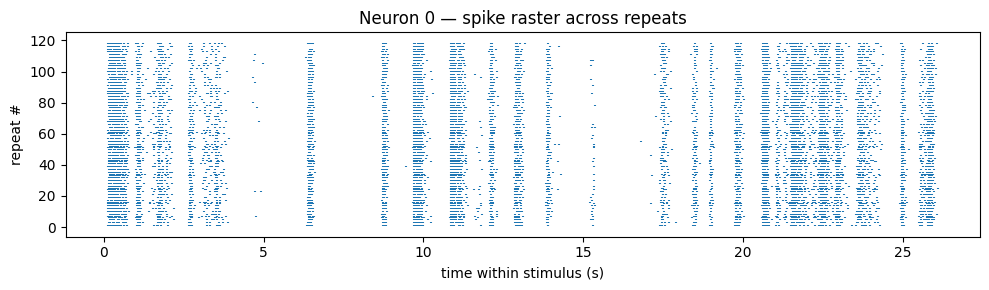

In [13]:
### Quick sanity checks and a first plot

if datas is not None:
    n_neurons = len(datas)

    # First neuron spikes
    spikes0 = np.asarray(datas[0], dtype=float)

    print(f"#neurons: {n_neurons}")
    print(f"Neuron 0: #spikes={spikes0.size}, max time={spikes0.max():.2f}s")

    # Raster within a single stimulus window (folded mod stim_t)
    plt.figure(figsize=(10, 3))
    
    # Fold spike times into the stimulus cycle:
    folded = spikes0 % stim_t       # position of each spike within one 26.5s repeat
    reps   = (spikes0 // stim_t).astype(int)  # which repetition the spike belongs to
    
    # Plot a raster: each spike is a vertical line at 'folded' time,
    # placed on the row of its repetition number.
    plt.vlines(folded, reps - 0.2, reps + 0.2)

    plt.xlabel("time within stimulus (s)")
    plt.ylabel("repeat #")
    plt.title("Neuron 0 — spike raster across repeats")
    plt.tight_layout()
    plt.show()

**Question B1.** Assuming a homogeneous Poisson process over the whole recording for neuron 0, infer its spiking rate. Specifically:  
**(i)** compute and plot the posterior $P(\theta \mid y)$ under the same Uniform($\theta\ge0$) prior;  
**(ii)** compute the posterior mean, variance, and MLE.

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

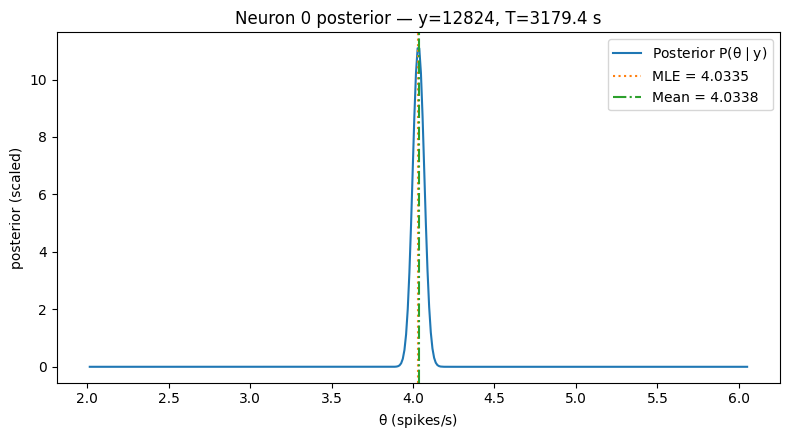

Estimators for neuron 0:  y=12824,  T=3179.37 s
  MLE        : 4.033505
  Post. mean : 4.033819
  Post. var  : 0.00126875


In [14]:
# Select neuron 0 spike times
spikes0 = np.asarray(datas[0], dtype=float)

T = spikes0.max()    # Observation time
y = spikes0.size        # Spike count   

# Build θ grid for plotting
theta_grid = np.linspace(0.5*(y / T), 1.5 * (y / T), 400)  # dynamic range ~0.5×MLE to ~1.5×MLE

post_vals = posterior(theta_grid, y, T)

# Estimators
theta_mean, theta_mle, theta_var = estimators_for_count(y, T)

# Plot posterior with markers
plt.figure(figsize=(8, 4.5))
plt.plot(theta_grid, post_vals, label="Posterior $P(\\theta \\mid y)$")
plt.axvline(theta_mle,  color="C1", ls=":",  label=f"MLE = {theta_mle:.4f}")
plt.axvline(theta_mean, color="C2", ls="-.", label=f"Mean = {theta_mean:.4f}")
plt.xlabel("$\\theta$ (spikes/s)")
plt.ylabel("posterior (scaled)")
plt.title(f"Neuron 0 posterior — y={y}, T={T:.1f} s")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Estimators for neuron 0:  y={y},  T={T:.2f} s")
print(f"  MLE        : {theta_mle:.6f}")
print(f"  Post. mean : {theta_mean:.6f}")
print(f"  Post. var  : {theta_var:.8f}")

**Question B2.** Simulate a Poisson process using your posterior mean rate for neuron 0 over the same duration **T**.  
Compare:
- raster **within a single stimulus window** (use modulo `stim_t`),  
- **inter-spike interval** distributions (data vs simulation).

**Bonus:** overlay the theoretical exponential inter-spike interval ISI density $ f(\Delta t) = \theta e^{-\theta \Delta t} $.

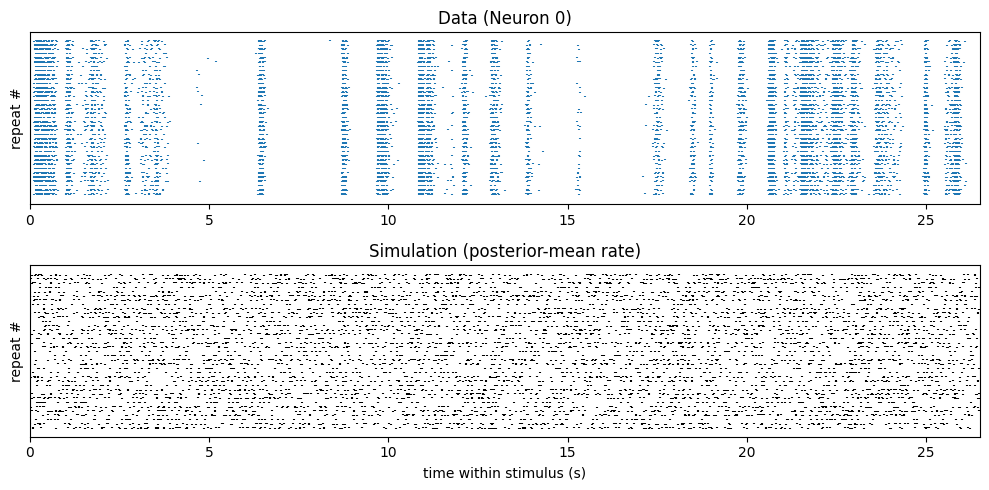

In [15]:
# Simulate Poisson spikes over the same duration T
y_sim = rng.poisson(theta_mean * T)
sim_times = np.sort(rng.uniform(0.0, T, size=y_sim))


# --- Folded raster comparison (within one stimulus period) ---

# Fold spike times into the stimulus cycle
fold_data = spikes0 % stim_t
rep_data  = (spikes0 // stim_t).astype(int)

fold_sim  = sim_times % stim_t
rep_sim   = (sim_times // stim_t).astype(int)

plt.subplots(2, 1, figsize=(10, 5))

# Data raster
plt.subplot(2, 1, 1)
plt.title("Data (Neuron 0)")
plt.vlines(fold_data, rep_data - 0.2, rep_data + 0.2)
plt.xlim(0, stim_t)
plt.ylabel("repeat #")
plt.tick_params(left=False, labelleft=False)

# Simulation raster
plt.subplot(2, 1, 2)
plt.title("Simulation (posterior-mean rate)")
plt.vlines(fold_sim, rep_sim - 0.2, rep_sim + 0.2, color="black")
plt.xlim(0, stim_t)
plt.xlabel("time within stimulus (s)")
plt.ylabel("repeat #")
plt.tick_params(left=False, labelleft=False)

plt.tight_layout()
plt.show()


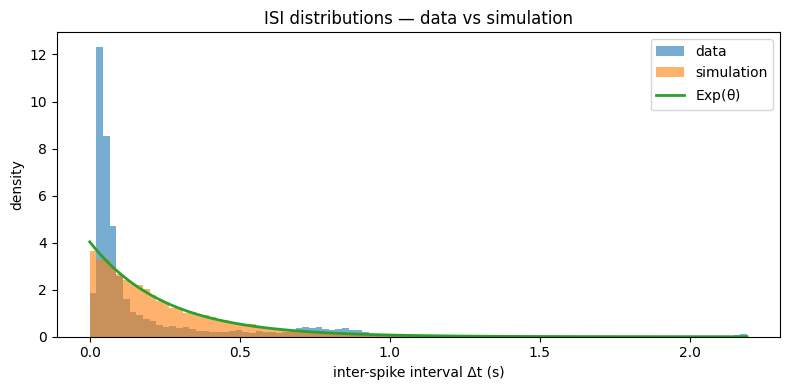

Simulation summary: y_sim=12693, y_data=12824


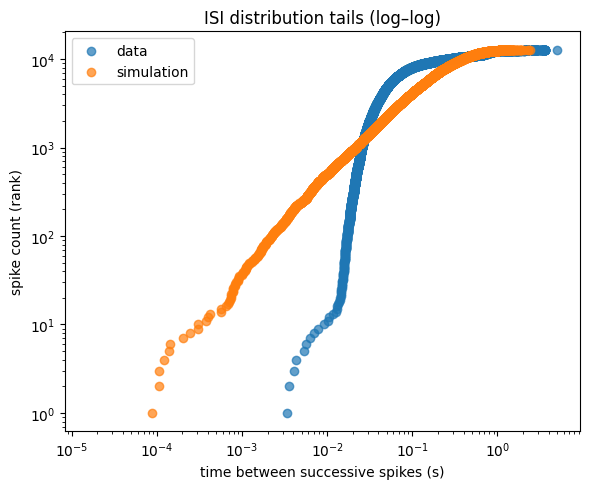

In [16]:
# --- ISI comparison with exponential overlay ---
def isi(x):
    x = np.asarray(x)
    if x.size < 2:
        return np.array([])
    return np.diff(np.sort(x))

isi_data = isi(spikes0)
isi_sim  = isi(sim_times)

plt.figure(figsize=(8, 4))
bins = np.linspace(0, np.percentile(np.concatenate([isi_data, isi_sim]), 99), 100)
plt.hist(isi_data, bins=bins, density=True, alpha=0.6, label="data")
plt.hist(isi_sim,  bins=bins, density=True, alpha=0.6, label="simulation")

# Exponential ISI density for rate = theta_hat
t_line = np.linspace(0, bins.max(), 300)
plt.plot(t_line, theta_mean * np.exp(-theta_mean * t_line), lw=2, label=r"Exp($\theta$)")

plt.xlabel("inter-spike interval Δt (s)")
plt.ylabel("density")
plt.title("ISI distributions — data vs simulation")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Simulation summary: y_sim={y_sim}, y_data={y}")

# --- 3. ISI log–log scatter comparison ---
plt.figure(figsize=(6, 5))
plt.scatter(np.sort(isi_data), np.arange(len(isi_data)), label="data", alpha=0.7)
plt.scatter(np.sort(isi_sim),  np.arange(len(isi_sim)),  label="simulation", alpha=0.7)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("time between successive spikes (s)")
plt.ylabel("spike count (rank)")
plt.title("ISI distribution tails (log–log)")
plt.legend()
plt.tight_layout()
plt.show()

# Optional tasks

**Question C1** (Theory): Prove that if the event rate is constant $\theta$, then the number of events $N(T)$ observed in a time window of duration $T$ follows a Poisson distribution with mean $\theta T$:
$$
\Pr[N(T)=k] = e^{-\theta T}\,\frac{(\theta T)^k}{k!}, \quad k=0,1,2,\dots
$$

## Derivation of the Poisson distribution

#### Intuition

The **Poisson distribution** can be obtained as a limit of the **Binomial distribution**, which describes the number of successes in a fixed number of independent Bernoulli trials.  
Suppose events occur independently at a constant average rate $\theta$ (events per unit time).  

- Divide the total interval $T$ into $n = T / \Delta t$ small sub-intervals of length $\Delta t$.  
- In each sub-interval, the probability of an event is approximately $p = \theta \Delta t$.  
- The total number of events in $T$ is then modeled as a Binomial random variable with parameters $(n, p)$:  
Letting $\Delta t \to 0$ (so $n \to \infty$) while keeping the expected number of events constant:
$$
np = \theta T = \lambda.
$$
gives the Poisson distribution with parameter $\lambda$.

---

#### Setup
Consider $n$ independent Bernoulli trials, each with success probability $p$.  
The number of successes $X$ follows a **Binomial distribution**:

$$
P(X=k) = \binom{n}{k} p^k (1-p)^{n-k}, \qquad k=0,1,2,\dots,n.
$$

### Rare-event limit
Suppose:
- $n$ is large (many trials),  
- $p$ is small (rare events),  
- the expected number of events is finite: $np = \lambda$.

Then $p = \lambda/n$. In our case, $\lambda = \theta T$ is the expected number of events in time $T$.

Substitute into the Binomial pdf:

$$
P(X=k) = \binom{n}{k} \Big(\tfrac{\lambda}{n}\Big)^k \Big(1 - \tfrac{\lambda}{n}\Big)^{n-k}.
$$

1. Limit of the first part:

$$
\binom{n}{k} \Big(\tfrac{\lambda}{n}\Big)^k \approx \frac{\lambda^k}{k!} \quad (n \to \infty).
$$

2. Limit of the second part:
$$
\lim_{n\to\infty}\Big(1 - \tfrac{\lambda}{n}\Big)^n = e^{-\lambda},
$$
and
$$
\Big(1 - \tfrac{\lambda}{n}\Big)^{-k} \to 1.
$$

### Result
Taking the limit as $n\to\infty$:
$$
P(X=k) = \frac{\lambda^k}{k!} e^{-\lambda}, \qquad k=0,1,2,\dots
$$

This is the **Poisson distribution** with parameter $\lambda$ (the expected number of events).
